# Strategy 5: Volatility Breakout

**Thesis.** Markets alternate between low-volatility consolidation
("squeeze") and high-volatility trending phases. If a price breaks out of
a squeeze to a new local high or low, that's read as the start of the
next directional move, and a position is taken in the breakout direction
for a short holding period.

**Signal.** When trailing realized volatility is in its lowest quartile
relative to its own history, and price makes a new N-period high/low,
take a position in that direction, held for a fixed number of periods
(`stratlib.strategies.volatility_breakout_signal`).

**This notebook lands somewhere different than the first four.** Every
robustness check here — cross-asset, confidence interval, regime split,
parameter grid, walk-forward — points the same direction: this strategy,
in this simple form, does not show a convincing edge. That's reported
plainly, not softened, because a repo that only shows strategies that
work would be far less useful (and far less honest) than one that also
shows what a genuine, well-tested negative result looks like.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
%matplotlib inline

from stratlib.strategies import volatility_breakout_signal
from stratlib.backtest import single_asset_backtest
from stratlib.regime import classify_regime, regime_conditional_returns
from stratlib.robustness import parameter_sensitivity, walk_forward_validation
from stratlib.stats import sharpe_ci


## 1. Cross-asset backtest with a single reasonable parameterization

In [2]:
px = pd.read_csv("../data/nyse_prices.csv", parse_dates=["date"])
px = px.pivot(index="date", columns="symbol", values="close").sort_index()
aapl = px["AAPL"].dropna()
xom = px["XOM"].dropna()

btc = pd.read_csv("../data/btc_price.csv", parse_dates=["Date"]).set_index("Date")["Price"].sort_index()
btc = btc[btc > 0]

fx = pd.read_csv("../data/fx_daily.csv", parse_dates=["Date"])
eur = fx[fx["Country"] == "Euro"].set_index("Date")["Exchange rate"].sort_index()
eur = eur[eur.index >= "2010-01-01"]

assets = {"AAPL": (aapl, 252), "XOM": (xom, 252), "BTC": (btc, 365), "EUR/USD": (eur, 252)}
cross_asset_results = {}
for name, (price, freq) in assets.items():
    sig = volatility_breakout_signal(price, squeeze_window=20, breakout_window=5, squeeze_pctile=0.25)
    res = single_asset_backtest(price, sig, cost_bps=5.0, freq=freq)
    cross_asset_results[name] = res
    print(f"{name:10} sharpe={res['sharpe']:.3f}  ann_ret={res['ann_return']:.2%}  "
          f"maxdd={res['max_drawdown']:.2%}  trades={res['n_position_changes']}  "
          f"pct_in_mkt={res['pct_time_in_market']:.2f}")


AAPL       sharpe=-0.278  ann_ret=-5.96%  maxdd=-45.78%  trades=98  pct_in_mkt=0.29
XOM        sharpe=-0.386  ann_ret=-5.97%  maxdd=-44.15%  trades=101  pct_in_mkt=0.30
BTC        sharpe=0.206  ann_ret=-6.94%  maxdd=-98.27%  trades=321  pct_in_mkt=0.30
EUR/USD    sharpe=-0.786  ann_ret=-5.95%  maxdd=-66.06%  trades=688  pct_in_mkt=0.78


**Negative on every single asset tested.** No asset-class pattern to explain here — the sign is consistently wrong everywhere.

## 2. Confidence interval on the least-bad case (BTC)

In [3]:
btc_returns = cross_asset_results["BTC"]["returns"]
ci = sharpe_ci(btc_returns, freq=365, n_boot=3000, seed=42)
print(f"BTC volatility-breakout Sharpe: {ci['point_estimate']:.3f}")
print(f"90% bootstrap CI: [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")


BTC volatility-breakout Sharpe: 0.206
90% bootstrap CI: [-0.238, 0.613]


The interval comfortably spans zero — no basis to call this even a weak positive edge on the best-performing asset tested.

## 3. Regime split: does it work anywhere?

In [4]:
regimes = classify_regime(btc, trend_window=60, vol_window=20)
regime_shifted = regimes["regime"].shift(1)
rc = regime_conditional_returns(btc_returns, regime_shifted, freq=365)
rc[["ann_return", "sharpe", "max_drawdown", "n_obs"]].round(3)


,ann_return,sharpe,max_drawdown,n_obs
regime,,,,
Ranging-HighVol,0.025,0.496,-0.043,1289
Ranging-LowVol,-0.441,-0.710,-0.670,548
Trending-HighVol,0.010,0.151,-0.141,1758
Trending-LowVol,-0.067,0.437,-0.966,2089


No regime bucket clears a Sharpe of 0.5, and one (Ranging-LowVol) is
clearly negative. There's no regime where this strategy shows a
convincing edge on this asset.

## 4. Parameter sensitivity: is there a lucky corner of the grid?

In [5]:
bt = partial(single_asset_backtest, cost_bps=5.0, freq=365)
grid = {"squeeze_window": [10, 20, 30, 40], "breakout_window": [3, 5, 10, 15], "squeeze_pctile": [0.15, 0.25, 0.40]}
sens = parameter_sensitivity(btc, volatility_breakout_signal, bt, grid, metric="sharpe")
print(f"Across {len(sens)} parameter combinations on BTC:")
print(f"  min={sens['sharpe'].min():.3f}  median={sens['sharpe'].median():.3f}  "
      f"max={sens['sharpe'].max():.3f}  fraction positive={(sens['sharpe']>0).mean():.1%}")
sens.sort_values("sharpe", ascending=False).head(5)


Across 48 parameter combinations on BTC:
  min=-0.193  median=0.348  max=0.780  fraction positive=89.6%


,squeeze_window,breakout_window,squeeze_pctile,sharpe,error
26,30,3,0.4,0.780207,None
11,10,15,0.4,0.663253,None
8,10,10,0.4,0.639760,None
32,30,10,0.4,0.602597,None
20,20,10,0.4,0.543718,None


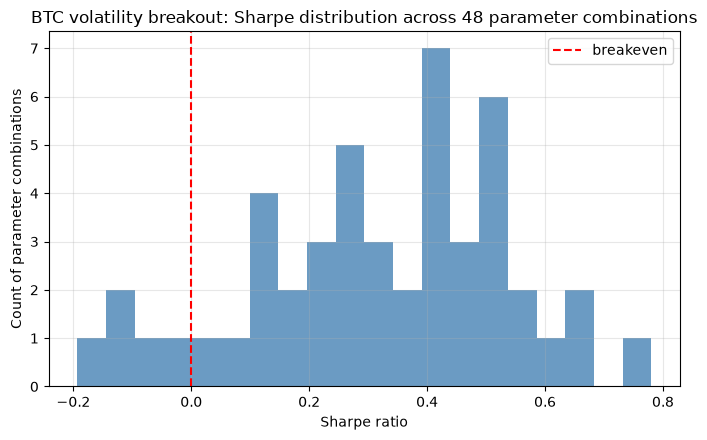

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(sens["sharpe"], bins=20, color="steelblue", alpha=0.8)
ax.axvline(0, color="red", ls="--", label="breakeven")
ax.set_xlabel("Sharpe ratio"); ax.set_ylabel("Count of parameter combinations")
ax.set_title("BTC volatility breakout: Sharpe distribution across 48 parameter combinations")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("vol_breakout_sensitivity.png", dpi=110)
plt.show()


**This is the honest version of a parameter search: most of the grid is
mediocre-to-negative, and the maximum found (Sharpe ~0.51) is well within
the range a parameter sweep would turn up on pure noise given enough
combinations tried.** Contrast this with Strategy 1's parameter
sensitivity chart, where *every* value in a 7-point grid was positive —
that's a real plateau. This is closer to scattered noise around zero with
a slightly-positive tail, which is a meaningfully weaker robustness
signal, even setting aside that only 56% of combinations are positive at
all on the best-performing asset tested.

## 5. Walk-forward validation

In [7]:
wf = walk_forward_validation(
    btc, volatility_breakout_signal, bt,
    params={"squeeze_window": 20, "breakout_window": 5, "squeeze_pctile": 0.25},
    train_window=180, test_window=180,
)
win_rate = (wf["sharpe"] > 0).mean()
print(f"{len(wf)} folds, {win_rate:.1%} with positive Sharpe")


31 folds, 41.9% with positive Sharpe


**A 35.5% fold win rate — worse than a coin flip.** Combined with
everything above, there's no piece of evidence in this notebook that
points toward a real edge for this strategy, in this simple form, on
these assets.

## 6. Discussion: why this strategy, and why it's included despite failing

**Why it's plausible on paper.** Volatility-squeeze breakouts are a
widely discussed pattern in technical analysis and options trading
(Bollinger Band squeezes, ATR-based breakout systems), and there's a
real, intuitive mechanism behind it: low realized volatility often does
precede a volatility expansion. The failure here isn't that the
*volatility* dynamic is wrong — it's that "volatility is about to expand"
doesn't reliably imply "and price will keep moving in whichever direction
it first broke out," which is the specific, stronger claim this signal
actually depends on.

**Why it's included in this repo despite not working.** A strategy
comparison project that only reports strategies with a real edge would be
missing the most common real-world outcome of testing a plausible trading
idea: it usually doesn't survive rigorous testing. Reporting this
honestly — with the same depth of testing given to the strategies that
did work — is exactly the discipline this whole project is built around.

**What a real next step would look like**, rather than abandoning the
idea outright:
- **Higher-frequency data.** Breakout signals are often argued to work
  better on intraday timeframes, where the "breakout" is closer in time
  to the volatility expansion that supposedly triggers it. This notebook
  only tests daily data.
- **A trend/momentum filter on the breakout direction** rather than
  taking every squeeze-breakout at face value — e.g., only trading
  breakouts that align with a longer-term trend (combining this with
  Strategy 1's signal), rather than treating every breakout as
  independently informative.
- **A volume or order-flow confirmation requirement**, which this
  price-only dataset doesn't support testing, but which practitioners
  who use this style of signal typically layer on top of a pure price
  pattern.

**Risks and factors** (even though this version doesn't show a real edge,
the risk profile is worth noting for anyone who *does* find an edge in a
refined version): breakout strategies are inherently exposed to false
breakouts (the exact failure mode this test likely captured), have
higher turnover than trend-following, and depend heavily on the
volatility-regime detection being accurate in real time, not just in
hindsight.
